<a href="https://colab.research.google.com/github/Sina-Haz/fastai-kaggle/blob/main/Convolutions_%26_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from fastai.vision.all import *

In [3]:
# Today we will try to get near 100% accuracy on MNIST (better than we can do with any MLP) using CNN
# We want to understand how to apply convolutions on images and perhaps then try with CIFAR (for rank 3 tensors)

path = untar_data(URLs.MNIST)

path.ls()

(#2) [Path('/root/.fastai/data/mnist_png/testing'),Path('/root/.fastai/data/mnist_png/training')]

In [4]:
trn_imgs = get_image_files(path/'training')

idx = np.random.randint(0, len(trn_imgs))

img = Image.open(trn_imgs[idx]) # If we use PILImage.create() -> loads in as RGB

img

In [5]:
# To work with the image data in pytorch we can actually directly convert from PIL to tensor
img_t = tensor(img)

img_t.shape

torch.Size([28, 28])

### Convolutions and Kernels

Now that we can load in our images, we want to define some kernels in order to convolve them with the images.

The kernel is simply a small matrix
 - We slide this smaller matrix across our image (pixel by pixel)
 - At each point we compute a dot product b/w the kernel and the portion of the image that it's aligned with
 - If we don't skip any pixels (i.e. we __Stride__ by 1) then the result will be the same size as the original
    - If we have a Stride length of 2 -> the result is half the size of the original image

It's important to note that in the pure math context:
1. Convolutions usually involve flipping the kernel (this has nice properties but not necessary for image processing so most libraries don't do this)
2. Usually the size of the resulting convolution is bigger than the original, but here

In [7]:
# This will detect top edges (above it the negatives will cancel out, and the positives will only contribute)
kernel = tensor([[-1., -1., -1], [0, 0, 0], [1, 1, 1]]).float()
img_t = img_t.float()

(img_t[0:kernel.shape[0], 0:kernel.shape[1]]*kernel).sum(), img_t[0:kernel.shape[0], 0:kernel.shape[1]] # unsurprisingly in the top corner there's no result as the image is all zeros here

(tensor(0.),
 tensor([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]))

tensor(215.)


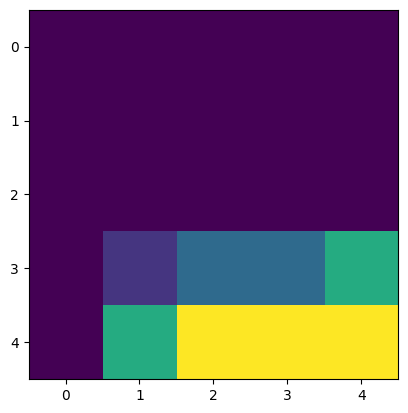

In [9]:
# Now we can try in the middle of the image
px = 10
print((img_t[px:px+kernel.shape[0], px:px+kernel.shape[1]]*kernel).sum()) # Wow seem's like here there's a top edge

plt.imshow(img_t[px-1:px+kernel.shape[0]+1, px-1:px+kernel.shape[1]+1]); # show the patch -> yep there's a top edge here!

torch.Size([25, 25])


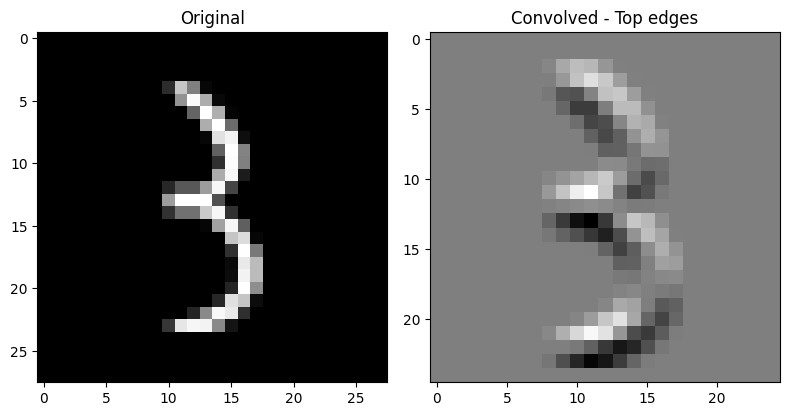

In [10]:
# Ok now let's code a simple function to apply a kernel over an image:
def simple_conv(img, kernel):
  kH, kW = kernel.shape

  res = []
  for i in range(img.shape[0]-kH):
    row = []
    for j in range(img.shape[1]-kW):
      row.append((img[i:i+kH, j:j+kW]*kernel).sum())
    res.append(row)
  return tensor(res)

convolved = simple_conv(img_t, kernel)

print(convolved.shape) # we can see that the result is slightly smaller -> this is b/c we used no padding

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(img_t, cmap='gray')
axs[0].set_title("Original")


axs[1].imshow(convolved, cmap='gray')
axs[1].set_title("Convolved - Top edges")

plt.tight_layout()
plt.show()

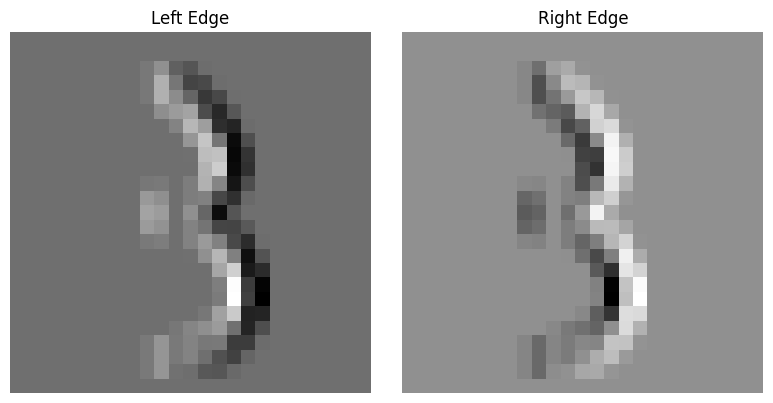

In [11]:
# Let's do this one more time with a kernel for sensing left/right edges
left_edge = tensor([[-1,1,0],
                    [-1,1,0],
                    [-1,1,0]]).float()

right_edge = torch.flip(left_edge, [0, 1]) # flip

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(simple_conv(img_t, left_edge), cmap='gray')
axs[0].set_title("Left Edge")
axs[0].axis('off')

axs[1].imshow(simple_conv(img_t, right_edge), cmap='gray')
axs[1].set_title("Right Edge")
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Just going to make this side by side a function
def show_both(im1, im2, cmap='gray'):
  fig, axs = plt.subplots(1, 2, figsize=(6,3))
  axs[0].imshow(im1, cmap)
  axs[1].imshow(im2, cmap)


### Convolutions with PyTorch

Now that we've seen what convolutions can do with a very simple function let's experiment with pytorch's function and play around with parameters such as:
 - Padding
 - Stride length
 - Bias
 - Dilation??

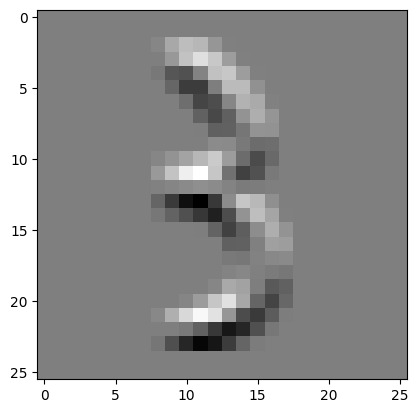

In [13]:
# Convolutions with torch:

# For pytorch's conv2d to work we need to add batch and channel dimensions which it expects
img_t = img_t.reshape(1, 1, 28, 28)  # Add batch and channel dimensions
kernel = kernel.reshape(1, 1, 3, 3) # Add batch and channel dimensions


# with default values uses no padding (so output may not be same shape as output) -> also pytorch conv expects either a rank 3 tensor or rank 4
res = F.conv2d(img_t, kernel)
plt.imshow(res[0, 0], cmap='gray'); # so pretty much the same output as our simple conv with just the default settings

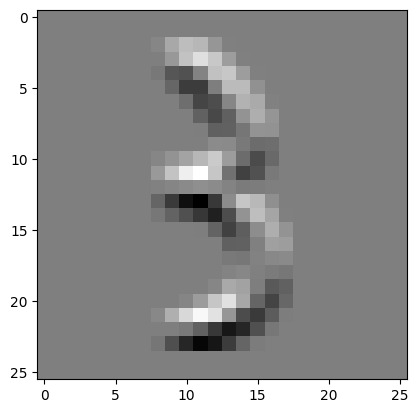

In [14]:
# Ok how about if we add some bias term? will this just generally lighten the image?

res2 = F.conv2d(img_t, kernel, bias=tensor([2.0]))
plt.imshow(res2[0, 0], cmap='gray'); # didn't change much -> probably more useful in different contexts

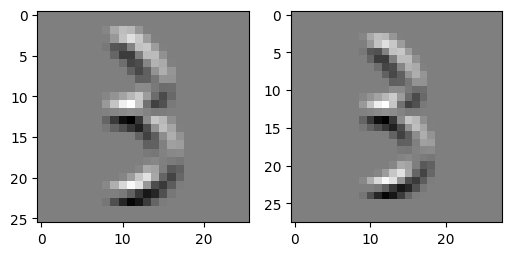

In [15]:
# Let's now try with different padding
res3 = F.conv2d(img_t, kernel, padding='same')

# side by side you can see that by using padding it preserved the original dimensions of the image, the non-padded one seems more zoomed in
show_both(res[0, 0], res3[0, 0])


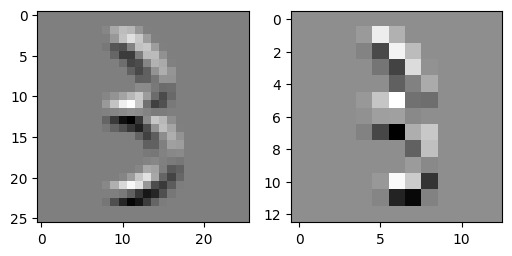

In [18]:
# Now let's try with stride length of 2 or 3
res4 = F.conv2d(img_t, kernel, stride=2)

# Wow now it looks much different -> almost like a lower res version of the image with stride=1, it's also clearly half the size
show_both(res[0, 0], res4[0, 0])

torch.Size([1, 1, 26, 26]) torch.Size([1, 1, 24, 24])


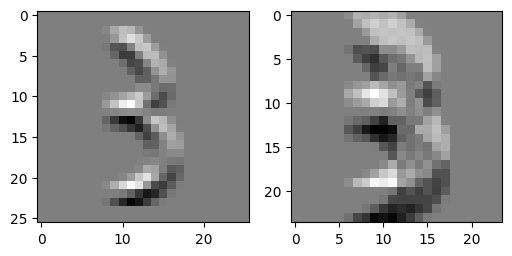

In [19]:
# Now let's try with dilation
res5 = F.conv2d(img_t, kernel, stride=1, dilation=2)

# Huh dilation looks very strange -> it kind of looks like when you look at something cross eyed
show_both(res[0, 0], res5[0, 0])
print(res.shape, res5.shape)

A note on convolution "settings":
1. Padding: pretty straightforward, implicitly pads input (w/ 0's) in a way s.t. convolved input has same shape as original
2. Stride: can choose to skip over every other pixel (can actually have different strides in x and y directions) -> this downsamples input and condenses it after convolution
3. Dilation: This actually makes the kernel work over a larger space by implicitly passing 0's to it s.t. each real kernel element is at least _dilation rate_ from it's neighbor
  - This allows the kernel to work over a larger area w/o increasing number of params
  - Captures global features better while being less effective at capturing local ones
  - Especially useful in image segmentation or when we have to capture larger more spaced out patterns in the image


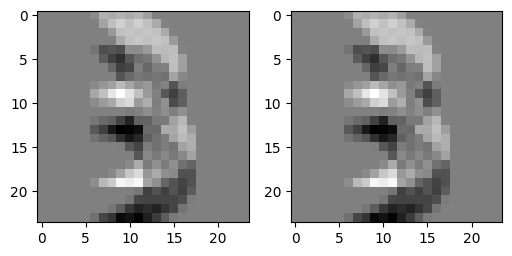

In [20]:
# To prove the note on dilations
dilated_kernel = tensor([[-1, 0, -1, 0, -1],
                         [0, 0, 0, 0, 0 ],
                         [0, 0, 0, 0, 0],
                         [0, 0, 0, 0, 0],
                         [1, 0, 1, 0, 1]]).float()

dilated_kernel = dilated_kernel.reshape(1, 1, 5, 5)

res6 = F.conv2d(img_t, dilated_kernel, stride=1, dilation=1)
show_both(res5[0,0], res6[0,0]) # as you can see the exact same

### Convolutional Neural Networks

Now that we understand convolutions we want to try and create a CNN from scratch. To do this it's important to understand how CNNs work
 - They use trainable convolutions as model parameters to create image features
 - They then aggregate information about these features using a technique called __Pooling__
 - After a few layers of convolutions + pooling we have a manageable number of activations which we feed to the _dense layer_
 - The _dense layer_ is just a bunch of linear layers + nonlinear activation functions

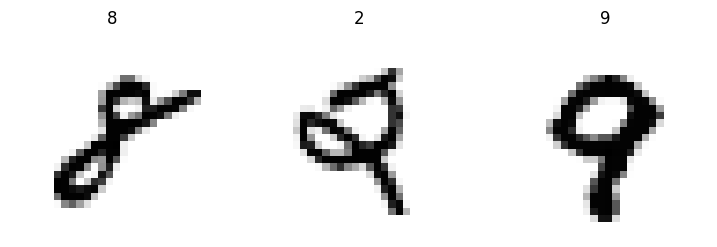

In [21]:
# First let's make a data loader for MNIST data
mnist_block = DataBlock(
    blocks = (ImageBlock(cls=PILImageBW), CategoryBlock),
    get_items = get_image_files,
    splitter = GrandparentSplitter(train_name='training', valid_name='testing'),
    get_y = parent_label
)

dls = mnist_block.dataloaders(path)

dls.show_batch(max_n=3)

In [41]:
simple_cnn = nn.Sequential(
    # params in and out channels: in_channel -> how many channels in images, for grayscale=1, RGB=3
    # Out channels corresponds to number of filters/kernels we want to use, each kernel convolved with input
    # leads to a new output which is it's own channel
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding='same'), # 4 x 28 x 28
    # Add a non-linearity
    nn.ReLU(),
    # Use pooling to aggregate features and reduce dimension
    nn.MaxPool2d(2), # 4 x 14 x 14
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding='same'), # 8 x 14 x 14
    nn.ReLU(),
    nn.MaxPool2d(2), # 8 x 7 x 7
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding='same'), # 16 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2), # 16 x 3 x 3
    nn.Flatten(),
    nn.Linear(16*3*3, 128),
    nn.ReLU(),
    nn.Linear(128,10)
)

In [42]:
xb, yb = dls.one_batch() # get a batch of data

print(xb.shape, yb.shape)

# make sure our model is on the right device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
simple_cnn = simple_cnn.to(device)

logits = simple_cnn(xb) # ok now looks like we get the correct output for our use case
print('labels', yb[:5], 'shape of logits', logits.shape )

torch.Size([64, 1, 28, 28]) torch.Size([64])
labels TensorCategory([4, 6, 2, 7, 2], device='cuda:0') shape of logits torch.Size([64, 10])


In [43]:
# Next let's define cross entropy loss for our task
x,y = torch.tensor(xb), torch.tensor(yb)

logits = simple_cnn(x)
def cross_entropy(logits, targets):
  # logits is shape: (bs, 10), targets is shape (bs, )
  targets = F.one_hot(targets, num_classes=10)
  log_probs = F.log_softmax(logits, dim=1)
  return -torch.mean(torch.sum(log_probs * targets, dim=1))

cross_entropy(logits, y)

<ipython-input-43-105bc3efb643>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x,y = torch.tensor(xb), torch.tensor(yb)


tensor(2.3110, device='cuda:0', grad_fn=<NegBackward0>)

SuggestedLRs(valley=0.004365158267319202, slide=0.013182567432522774)

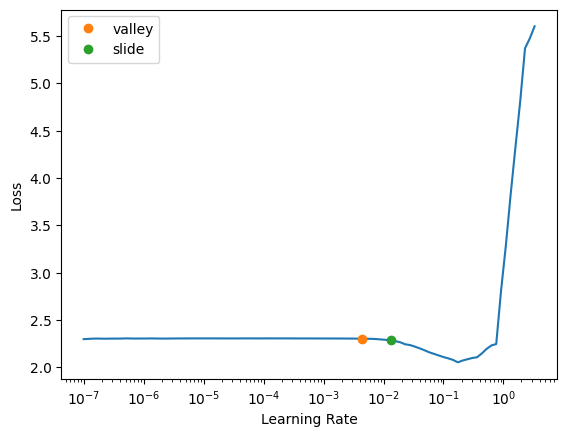

In [44]:
cnn = Learner(dls=dls, model=simple_cnn, loss_func = cross_entropy, metrics=accuracy).to_fp16()

cnn.lr_find(suggest_funcs=(valley, slide))  # instead of steep or default

In [45]:
cnn.summary() # Let's take a look at our model

Sequential (Input shape: 64 x 1 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 4 x 28 x 28    
Conv2d                                    40         True      
ReLU                                                           
____________________________________________________________________________
                     64 x 4 x 14 x 14    
MaxPool2d                                                      
____________________________________________________________________________
                     64 x 8 x 14 x 14    
Conv2d                                    296        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 8 x 7 x 7      
MaxPool2d                                                      
____________________________________________________________________________
                     64 x 16 x 7 

In [46]:
cnn.fit(n_epoch=5, lr=0.01)

epoch,train_loss,valid_loss,accuracy,time
0,0.109471,0.089779,0.971300,00:51
1,0.095977,0.075296,0.976300,00:50
2,0.083567,0.064921,0.979700,00:49
3,0.063185,0.070323,0.977500,00:52
4,0.073661,0.080888,0.973700,00:49


SuggestedLRs(valley=0.0020892962347716093)

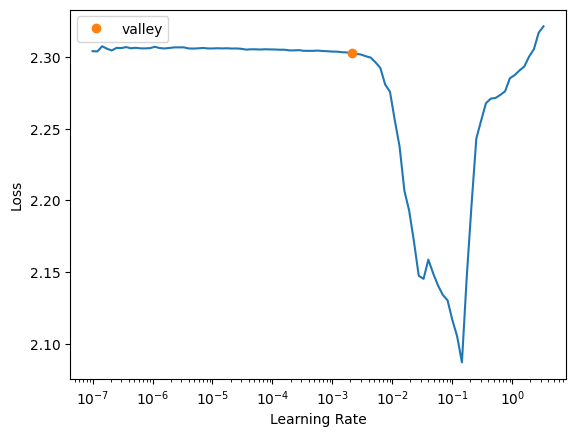

In [47]:
# Now let's experiment with using a model with slightly larger kernel size:
simple_cnn_ks5 = nn.Sequential(
    # params in and out channels: in_channel -> how many channels in images, for grayscale=1, RGB=3
    # Out channels corresponds to number of filters/kernels we want to use, each kernel convolved with input
    # leads to a new output which is it's own channel
    nn.Conv2d(1, 4, kernel_size=5, stride=1, padding='same'), # 4 x 28 x 28
    # Add a non-linearity
    nn.ReLU(),
    # Use pooling to aggregate features and reduce dimension
    nn.MaxPool2d(2), # 4 x 14 x 14
    nn.Conv2d(4, 8, kernel_size=5, stride=1, padding='same'), # 8 x 14 x 14
    nn.ReLU(),
    nn.MaxPool2d(2), # 8 x 7 x 7
    nn.Conv2d(8, 16, kernel_size=5, stride=1, padding='same'), # 16 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2), # 16 x 3 x 3
    nn.Flatten(),
    nn.Linear(16*3*3, 128),
    nn.ReLU(),
    nn.Linear(128,10)
).to(device)

cnn2 = Learner(dls=dls, model=simple_cnn_ks5, loss_func = cross_entropy, metrics=accuracy).to_fp16()

cnn2.lr_find()

In [48]:
cnn2.summary() # uses similar number of params but from lr find seems that loss will decrease better

Sequential (Input shape: 64 x 1 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 4 x 28 x 28    
Conv2d                                    104        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 4 x 14 x 14    
MaxPool2d                                                      
____________________________________________________________________________
                     64 x 8 x 14 x 14    
Conv2d                                    808        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 8 x 7 x 7      
MaxPool2d                                                      
____________________________________________________________________________
                     64 x 16 x 7 

In [50]:
cnn2.fit(n_epoch=5,lr=0.01)

epoch,train_loss,valid_loss,accuracy,time
0,0.094322,0.074017,0.978100,00:49
1,0.092789,0.069239,0.978100,00:49
2,0.117010,0.109045,0.966200,00:50
3,0.092853,0.084392,0.975800,00:52
4,0.081166,0.074787,0.980200,00:56


SuggestedLRs(valley=0.002511886414140463)

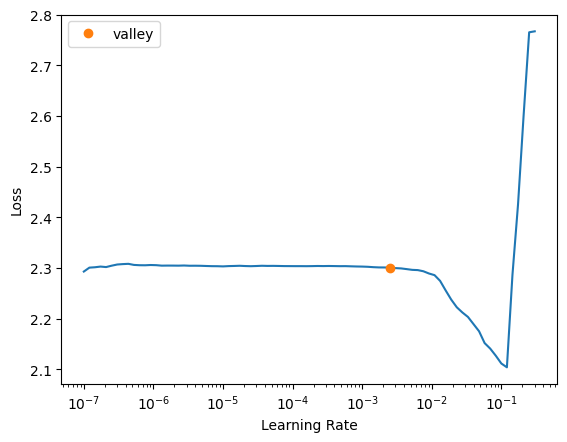

In [51]:
# I think that the larger kernel size is better but our model is starting to overfit
# To try and alleviate this we can use dropout to generalize better but it will require more training
cnn_ks5_dropout = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=5, stride=1, padding='same'), # 4 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2), # 4 x 14 x 14

    nn.Conv2d(4, 8, kernel_size=5, stride=1, padding='same'), # 8 x 14 x 14
    nn.ReLU(),
    nn.MaxPool2d(2), # 8 x 7 x 7

    nn.Conv2d(8, 16, kernel_size=5, stride=1, padding='same'), # 16 x 7 x 7
    nn.ReLU(),
    nn.Dropout2d(0.25),
    nn.MaxPool2d(2), # 16 x 3 x 3

    nn.Flatten(),
    nn.Linear(16*3*3, 128),
    nn.ReLU(),
    nn.Dropout(0.25),

    nn.Linear(128,10)
).to(device)

cnn3 = Learner(dls=dls, model=cnn_ks5_dropout, loss_func = cross_entropy, metrics=accuracy).to_fp16()

cnn3.lr_find()


In [53]:
cnn3.fit(8, lr=0.01) # train for longer since we are using dropout and harder to learn

epoch,train_loss,valid_loss,accuracy,time
0,0.196402,0.125006,0.961700,00:54
1,0.165828,0.109484,0.966900,00:56
2,0.161793,0.082338,0.975500,00:50
3,0.163155,0.085677,0.974100,00:50
4,0.151417,0.083046,0.975800,00:50
5,0.151173,0.098706,0.973200,00:51
6,0.170440,0.090087,0.972800,00:50
7,0.145290,0.082392,0.978000,00:51


In [54]:
# Looks a little worse but let's see how we do when dropout is turned off
cnn3.validate() # -> about the same as without dropoff actually but the learning is a little more consistent

(#2) [0.08239227533340454,0.9779999852180481]

SuggestedLRs(valley=0.004365158267319202)

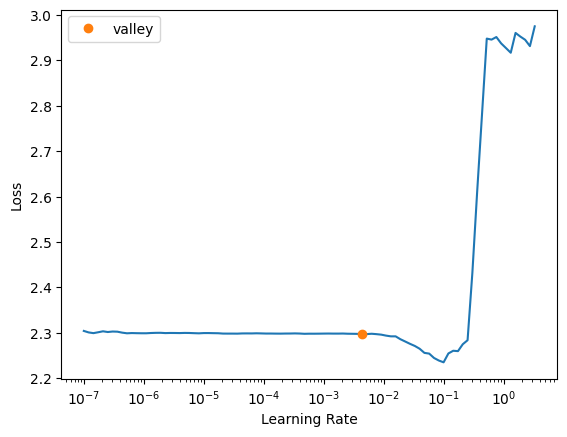

In [58]:
# Lastly we will utilize some data augmentation and see how this performs with the same architecture
mnist_block2 = DataBlock(
    blocks = (ImageBlock(cls=PILImageBW), CategoryBlock),
    get_items = get_image_files,
    splitter = GrandparentSplitter(train_name='training', valid_name='testing'),
    get_y = parent_label,
    batch_tfms = aug_transforms(size=24, min_scale=0.75)
)

dls2 = mnist_block2.dataloaders(path, bs=64)

cnn4 = Learner(dls2, cnn_ks5_dropout, loss_func = cross_entropy, metrics=accuracy).to_fp16()

cnn4.lr_find()

In [59]:
cnn4.fit(10, lr=0.01)

epoch,train_loss,valid_loss,accuracy,time
0,0.479440,0.276551,0.910500,01:03
1,0.438471,0.231217,0.929400,01:03
2,0.415757,0.225312,0.930500,01:02
3,0.406408,0.219404,0.930000,01:02
4,0.363176,0.179617,0.945200,01:03
5,0.389919,0.184196,0.944400,01:02
6,0.370456,0.166456,0.948000,01:02
7,0.355423,0.199904,0.941600,01:02
8,0.373923,0.162389,0.948100,01:02
9,0.353704,0.177586,0.945900,01:03


In [62]:
# let's see the tta accuracy:
preds, targs = cnn4.tta()
acc = accuracy(preds, targs)

print(acc) # solid but not better than our cnn with no augmentation

TensorBase(0.9710)


In [63]:
cnn4.validate() # nah seems that batch transforms is not the best for this dataset

(#2) [0.17758558690547943,0.945900022983551]

In [65]:
cnn3.fit(3, lr=0.01) # let's fit cnn3 for same amount of time

epoch,train_loss,valid_loss,accuracy,time
0,0.150284,0.089017,0.975700,00:51
1,0.137134,0.117445,0.972700,00:50
2,0.168309,0.082338,0.977300,00:50


### Conclusion
Ok that's all for now, in this notebook we went over convolutions, how they work, different augmentations to them and how to use them to train CNNs on images.